# SK1 - Ein Neuronales Netzwerk für MNIST

In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

Der `MLPClassifier` steht für Multi-Layer Perceptron Classifier. Dieser implementiert ein mehrschichtiges Perzeptron (ein künstliches neuronales Netzwerk) das durch den Backpropagation-Algorithmus trainiert wird.

Ein mehrschichtiges Perzeptron (MLP) ist ein Klassifikationsalgorithmus, der in der Lage ist, nicht-lineare Modelle zu lernen. Es besteht aus mindestens drei Schichten von Knoten: einer Eingabeschicht, einer oder mehreren "verborgenen" Schichten und einer Ausgabeschicht. Jede Schicht besteht aus Neuronen, wobei die Neuronen in einer Schicht mit denen in der nächsten Schicht verbunden sind.

Hier ist eine kurze Beschreibung, wie der MLPClassifier funktioniert:

1. **Initialisierung**: Zunächst werden die Gewichte des Netzwerks zufällig initialisiert.

2. **Feedforward**: Jedes Eingabedatum (ein Vektor) wird durch das Netzwerk geführt. Die Eingaben werden durch die Gewichte der Verbindungen zwischen den Neuronen modifiziert und die Ausgabe jedes Neurons wird durch eine Aktivierungsfunktion (wie die Sigmoid- oder ReLU-Funktion) bestimmt.

3. **Backpropagation**: Nachdem die Ausgabe des Netzwerks berechnet wurde, wird der Fehler (die Differenz zwischen der vorhergesagten und der tatsächlichen Ausgabe) berechnet. Dieser Fehler wird dann rückwärts durch das Netzwerk propagiert, wobei die Gewichte entsprechend angepasst werden, um den Fehler zu minimieren.

4. **Iteration**: Die Schritte 2 und 3 werden wiederholt, bis der Fehler unter einem bestimmten Schwellenwert liegt oder eine bestimmte Anzahl von Iterationen erreicht ist.

Die MLPClassifier-Klasse in sklearn hat viele Parameter, aber die wichtigsten sind:

- `hidden_layer_sizes`: Eine Liste, die die Anzahl der Neuronen in den verborgenen Schichten angibt.
- `activation`: Die Aktivierungsfunktion für die Neuronen. Dies kann 'logistic' (Sigmoid), 'tanh', 'relu' oder 'identity' sein.
- `solver`: Der Optimierer, der verwendet wird, um die Gewichte anzupassen. Dies kann 'lbfgs', 'sgd' (stochastischer Gradientenabstieg) oder 'adam' sein.
- `alpha`: Ein Regularisierungsparameter, der Overfitting verhindert.
- `learning_rate_init`: Die anfängliche Lernrate für die Gewichtsanpassungen.

Der `MLPClassifier` ist ein leistungsfähiges Werkzeug, aber er hat auch seine Nachteile. Er kann zum Beispiel anfällig für Overfitting sein, wenn das Netzwerk zu komplex ist. Außerdem kann er bei großen Datensätzen sehr langsam sein.

In [3]:
# Laden des MNIST-Datensatzes
X, y = fetch_openml('mnist_784', version=1, parser = 'auto', return_X_y=True)

In [ ]:
# Skalieren der Daten
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [ ]:
# Aufteilen des Datensatzes in Trainings- und Testdaten
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Erstellen des neuronalen Netzwerks
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=20, alpha=1e-4,
                    solver='sgd', verbose=10, random_state=1,
                    learning_rate_init=.1)

In [ ]:
# Trainieren des neuronalen Netzwerks
mlp.fit(X_train, y_train)

# Vorhersagen auf den Testdaten
y_pred = mlp.predict(X_test)

# Ausgabe der Genauigkeit
print("Accuracy: ", accuracy_score(y_test, y_pred))

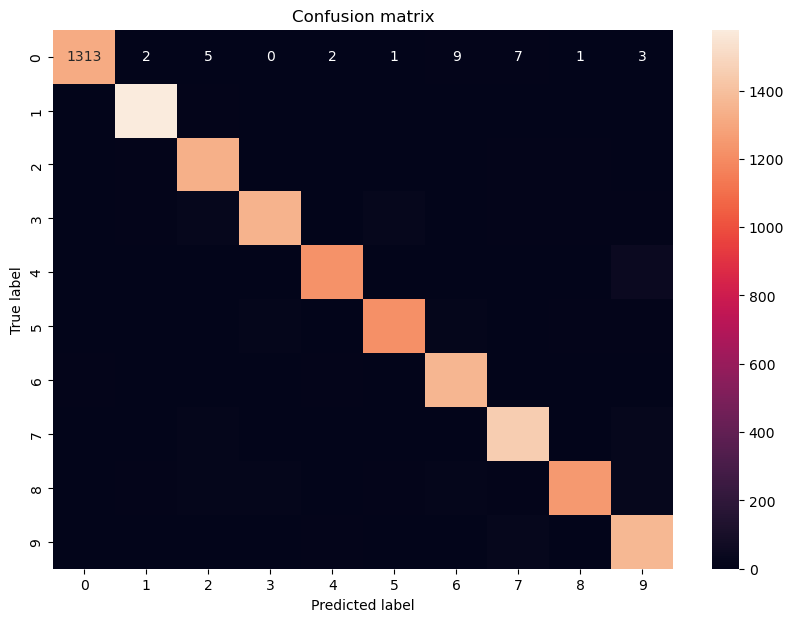

In [4]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Vorhersagen auf den Testdaten
y_pred = mlp.predict(X_test)

# Erstellen der Konfusionsmatrix
cm = confusion_matrix(y_test, y_pred)

# Visualisieren der Konfusionsmatrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()